# Polish Companies Bankruptcy (UCI) — Exploratory Data Analysis

**Purpose:** quantify class imbalance, missingness, distributional issues, and the feasibility of an imputation-focused GAN (GAIN / conditional imputation model).

**Data:** [UCI dataset 365](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data). Five independent forecasting-horizon cohorts (`1year`–`5year`), each with 64 financial ratios and binary class (`1` bankrupt, `0` non-bankrupt). **The cohort number denotes the financial-statement year within the prediction setup, not a firm-specific longitudinal time series.**

**Reproducibility:** all numerical results below are calculated by executing the notebook. Official UCI cohort label counts are given as a cross-check, not substitutes for empirical calculations. Analysis preserves unmodified features and missing values until the optional demonstration of leakage-safe preparation.

**Import:** Direct original UCI ZIP download with a manual Colab upload fallback.
**Output:** CSV summaries, PNG figures, optional download ZIP.

**Team workflow:** This notebook downloads the original public UCI archive automatically, caches it in `data/` for the current runtime, and never requires Google Drive or manual uploads. The `data/` directory should be in `.gitignore`. Colab resets its workspace between runtime sessions.


## 0. Environment and reproducibility

In [1]:
%pip -q install pandas numpy scipy scikit-learn matplotlib seaborn statsmodels requests nbformat

In [2]:
import os, io, re, zipfile, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from scipy.io import arff
from scipy.stats import chi2_contingency, skew
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.metrics import average_precision_score
from statsmodels.stats.multitest import multipletests
from IPython.display import display

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style='whitegrid', context='notebook')
OUT = Path('outputs/polish_eda')
OUT.mkdir(parents=True, exist_ok=True)
print('Output folder:', OUT.resolve())

Output folder: /content/outputs/polish_eda


## 1. Reproducible UCI download and parse

This GitHub-friendly loader downloads the original ZIP from UCI **once per runtime** and caches it in a repository-relative `data/` directory. No Drive mounting, local absolute paths, `ucimlrepo`, or file uploader required. Internet access is necessary for the first run. Nested ZIPs and ARFF files are handled automatically.

In [3]:
DATA_URL = 'https://archive.ics.uci.edu/static/public/365/polish%2Bcompanies%2Bbankruptcy%2Bdata.zip'
DATA_DIR = Path('data')
DATA_DIR.mkdir(parents=True, exist_ok=True)
ZIP_PATH = DATA_DIR / 'polish_companies_bankruptcy_uci365.zip'

# Cache raw UCI data for the current Colab/local runtime (do not commit data/).
if not ZIP_PATH.is_file():
    print('Downloading original archive from UCI...')
    response = requests.get(DATA_URL, timeout=120, headers={'User-Agent': 'Mozilla/5.0'})
    response.raise_for_status()
    # Fail early if the response is an HTML error or invalid ZIP.
    if not zipfile.is_zipfile(io.BytesIO(response.content)):
        raise ValueError('UCI did not return a ZIP archive. Check the official dataset page.')
    ZIP_PATH.write_bytes(response.content)
else:
    print('Using cached archive:', ZIP_PATH)

import hashlib
print('Archive SHA-256:', hashlib.sha256(ZIP_PATH.read_bytes()).hexdigest())

def unpack_arffs(blob, depth=0):
    if depth > 4:
        raise ValueError('Unexpected archive nesting depth')
    result = {}
    with zipfile.ZipFile(io.BytesIO(blob)) as archive:
        for name in archive.namelist():
            if name.endswith('/'):
                continue
            content = archive.read(name)
            if name.lower().endswith('.zip'):
                result.update(unpack_arffs(content, depth+1))
            elif name.lower().endswith('.arff'):
                result[Path(name).name.lower()] = content
    return result

raw_files = unpack_arffs(ZIP_PATH.read_bytes())
print('ARFF files found:', sorted(raw_files))
assert all(f'{i}year.arff' in raw_files for i in range(1,6)), 'Expected all five UCI ARFF cohorts'

def parse_cohort(name, content):
    data, metadata = arff.loadarff(io.StringIO(content.decode("utf-8-sig")))
    frame = pd.DataFrame(data)
    frame.columns = [str(c).strip().lower() for c in frame.columns]
    label_candidates = [c for c in frame if c in ['class', 'class_label', 'bankrupt']]
    if len(label_candidates) != 1:
        raise ValueError(f'{name}: unexpected label columns: {list(frame.columns)}')
    label = label_candidates[0]
    for col in frame:
        if frame[col].dtype == object:
            frame[col] = frame[col].map(lambda v: v.decode('utf-8') if isinstance(v, bytes) else v)
    frame = frame.rename(columns={label:'bankrupt'})
    frame['bankrupt'] = pd.to_numeric(frame['bankrupt'], errors='raise').astype(int)
    assert set(frame['bankrupt'].unique()) <= {0,1}
    feature_cols = [c for c in frame if c != 'bankrupt']
    frame[feature_cols] = frame[feature_cols].apply(pd.to_numeric, errors='coerce')
    # Standardize UCI attributes e.g. Attr1, attr1 into readable A1...A64.
    if len(feature_cols) != 64:
        raise ValueError(f'{name}: expected 64 ratios, found {len(feature_cols)}')
    rename = {}
    for j, col in enumerate(feature_cols, start=1):
        match = re.search(r'(\d+)$', col)
        rename[col] = f'A{int(match.group(1))}' if match else f'A{j}'
    frame = frame.rename(columns=rename)
    if len(set(rename.values())) != 64:
        raise ValueError(f'{name}: duplicate normalized attribute names')
    frame.insert(0, 'cohort', name.replace('.arff',''))
    return frame

cohorts = {f'{i}year':parse_cohort(f'{i}year',raw_files[f'{i}year.arff']) for i in range(1,6)}
df = pd.concat(cohorts.values(), ignore_index=True)
features = [f'A{i}' for i in range(1,65)]
assert df[features].shape[1] == 64
print('Pooled shape:', df.shape)
display(df.head())

Archive SHA-256: 17377929aa0b204bbf957e56462cf827c19fe4e2ce89f27dfbc77f9ea2bb16c9
ARFF files found: ['1year.arff', '2year.arff', '3year.arff', '4year.arff', '5year.arff']
Pooled shape: (43405, 66)


,cohort,A1,A2,A3,A4,A5,A6,A7,A8,A9,...,A56,A57,A58,A59,A60,A61,A62,A63,A64,bankrupt
0,1year,0.200550,0.37951,0.39641,2.0472,32.3510,0.38825,0.249760,1.33050,1.1389,...,0.121960,0.39718,0.87804,0.001924,8.4160,5.1372,82.658,4.4158,7.4277,0
1,1year,0.209120,0.49988,0.47225,1.9447,14.7860,0.00000,0.258340,0.99601,1.6996,...,0.121300,0.42002,0.85300,0.000000,4.1486,3.2732,107.350,3.4000,60.9870,0
2,1year,0.248660,0.69592,0.26713,1.5548,-1.1523,0.00000,0.309060,0.43695,1.3090,...,0.241140,0.81774,0.76599,0.694840,4.9909,3.9510,134.270,2.7185,5.2078,0
3,1year,0.081483,0.30734,0.45879,2.4928,51.9520,0.14988,0.092704,1.86610,1.0571,...,0.054015,0.14207,0.94598,0.000000,4.5746,3.6147,86.435,4.2228,5.5497,0
4,1year,0.187320,0.61323,0.22960,1.4063,-7.3128,0.18732,0.187320,0.63070,1.1559,...,0.134850,0.48431,0.86515,0.124440,6.3985,4.3158,127.210,2.8692,7.8980,0


## 2. Dataset overview and data integrity

Pooled records are **not necessarily unique companies**. Do not infer individual-company trajectories from these five cohorts or randomly split pooled data as if firm IDs were available.

In [4]:
overview = pd.DataFrame([{
    'cohort': k, 'rows': len(v), 'features':len(features),
    'nonbankrupt':int((v.bankrupt==0).sum()), 'bankrupt':int((v.bankrupt==1).sum()),
    'bankrupt_pct':round(100*v.bankrupt.mean(),3),
    'any_missing_rows_pct':round(100*v[features].isna().any(axis=1).mean(),2),
    'missing_cell_pct':round(100*v[features].isna().to_numpy().mean(),2),
} for k,v in cohorts.items()])
assert overview['rows'].tolist() == [7027,10173,10503,9792,5910], 'Official cohort sizes changed!'
assert overview['bankrupt'].tolist() == [271,400,495,515,410], 'Official UCI bankrupt counts differ!'
display(overview)
overview.to_csv(OUT/'cohort_overview.csv',index=False)

print('Total missing numeric cells:',int(df[features].isna().sum().sum()))
print('All-missing columns:',df[features].columns[df[features].isna().all()].tolist())
print('Constant/non-informative columns (ignoring NaN):',df[features].columns[df[features].nunique(dropna=True)<=1].tolist())
print('Exact duplicate rows within each cohort:', sum(v.duplicated().sum() for v in cohorts.values()))
print('Infinite values in numeric ratios:',int(np.isinf(df[features].to_numpy(dtype=float)).sum()))

,cohort,rows,features,nonbankrupt,bankrupt,bankrupt_pct,any_missing_rows_pct,missing_cell_pct
0,1year,7027,64,6756,271,3.857,54.55,1.30
1,2year,10173,64,9773,400,3.932,59.82,1.87
2,3year,10503,64,10008,495,4.713,53.49,1.47
3,4year,9792,64,9277,515,5.259,51.30,1.40
4,5year,5910,64,5500,410,6.937,48.71,1.23


Total missing numeric cells: 41322
All-missing columns: []
Constant/non-informative columns (ignoring NaN): []
Exact duplicate rows within each cohort: 401
Infinite values in numeric ratios: 0


## 3. Class imbalance — per cohort and pooled

We report both counts and the non-bankrupt-to-bankrupt ratio. Class prevalence changes by horizon; **do not treat the cohorts as successive observations from the same company**.

,cohort,rows,nonbankrupt,bankrupt,bankrupt_pct,majority_to_minority
0,1year,7027,6756,271,3.857,24.93
1,2year,10173,9773,400,3.932,24.43
2,3year,10503,10008,495,4.713,20.22
3,4year,9792,9277,515,5.259,18.01
4,5year,5910,5500,410,6.937,13.41
5,pooled,43405,41314,2091,4.817,19.76


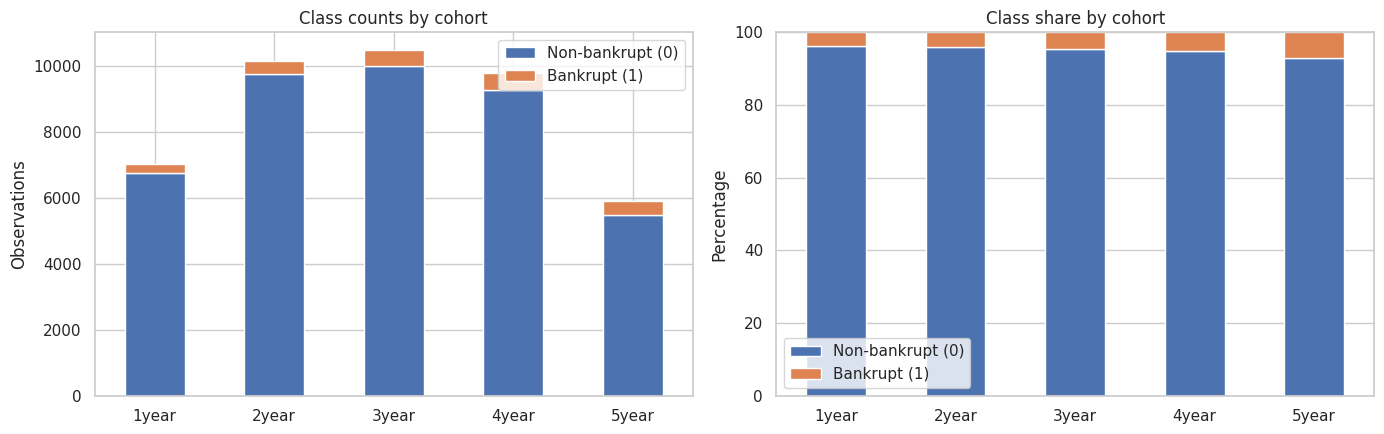

Always predicting non-bankrupt yields pooled accuracy: 95.18%; this is NOT a useful model.
No-skill precision/PR-AUC baseline (pooled prevalence): 0.0482


In [5]:
imbalance = overview[['cohort','rows','nonbankrupt','bankrupt','bankrupt_pct']].copy()
imbalance['majority_to_minority'] = (imbalance['nonbankrupt']/imbalance['bankrupt']).round(2)
pooled = {'cohort':'pooled', 'rows':len(df), 'nonbankrupt':int((df.bankrupt==0).sum()),
          'bankrupt':int((df.bankrupt==1).sum()), 'bankrupt_pct':round(100*df.bankrupt.mean(),3),
          'majority_to_minority':round((df.bankrupt==0).sum()/(df.bankrupt==1).sum(),2)}
imbalance = pd.concat([imbalance,pd.DataFrame([pooled])],ignore_index=True)
display(imbalance)
imbalance.to_csv(OUT/'class_imbalance.csv',index=False)

fig,axes=plt.subplots(1,2,figsize=(14,4.5))
counts = df.groupby(['cohort','bankrupt']).size().unstack(fill_value=0).reindex(cohorts.keys())
counts.columns=['Non-bankrupt (0)','Bankrupt (1)']
counts.plot(kind='bar',stacked=True,ax=axes[0]);axes[0].set(ylabel='Observations',title='Class counts by cohort',xlabel='')
axes[0].tick_params(axis='x',rotation=0)
(100*counts.div(counts.sum(axis=1),axis=0)).plot(kind='bar',stacked=True,ax=axes[1]);axes[1].set(ylabel='Percentage',title='Class share by cohort',xlabel='',ylim=(0,100))
axes[1].tick_params(axis='x',rotation=0)
plt.tight_layout();plt.savefig(OUT/'class_imbalance.png',dpi=160);plt.show()
print(f'Always predicting non-bankrupt yields pooled accuracy: {(df.bankrupt==0).mean():.2%}; this is NOT a useful model.')
print(f'No-skill precision/PR-AUC baseline (pooled prevalence): {df.bankrupt.mean():.4f}')

## 4. Missingness: feature-level, row-level, cohort-level

For an imputation GAN, determine the **number and location** of missing values—not just whether missing values exist.

,missing_n,missing_pct,observed_n
A37,18984,43.74,24421
A21,5854,13.49,37551
A27,2764,6.37,40641
A60,2152,4.96,41253
A45,2147,4.95,41258
A24,922,2.12,42483
A54,812,1.87,42593
A28,812,1.87,42593
A64,812,1.87,42593
A53,812,1.87,42593


Rows with >=1 missing attribute: 54.00%
Rows with >=10 missing attributes: 0.56%
Missing values per row quantiles:


,n_missing
0.00,0.0
0.25,0.0
0.50,1.0
0.75,1.0
0.90,2.0
0.95,3.0
0.99,7.0
1.00,41.0


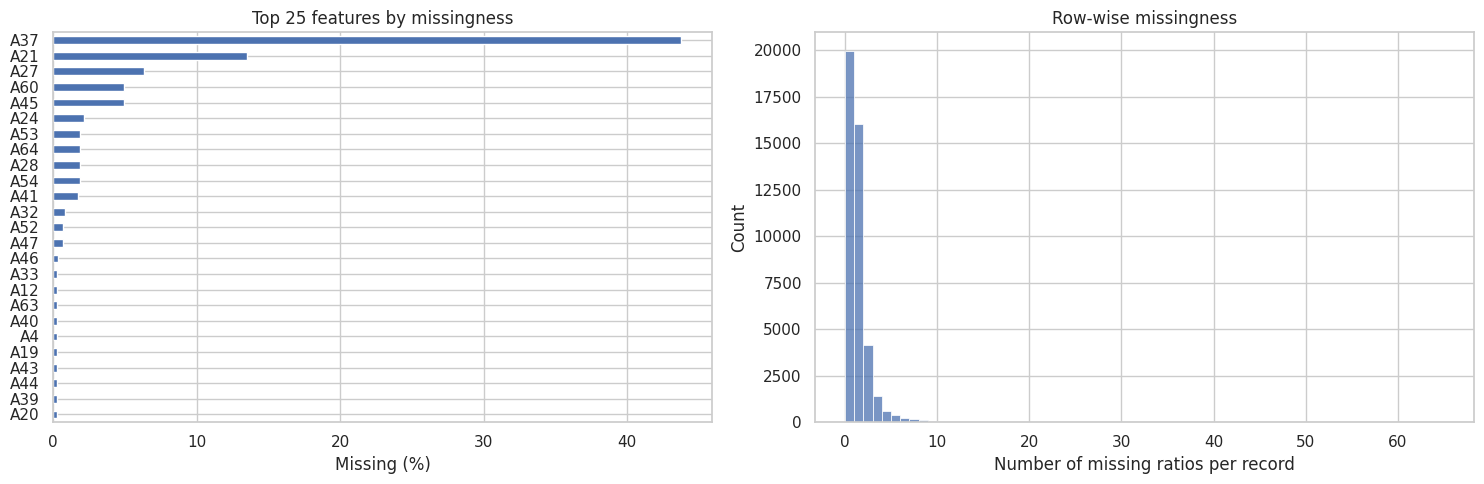

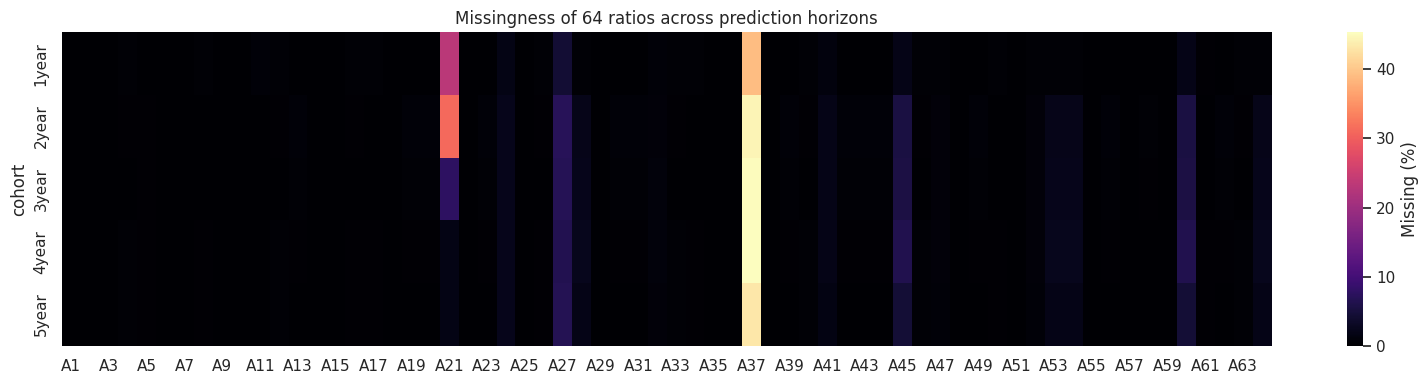

In [6]:
miss = df[features].isna()
missing_by_feature = pd.DataFrame({
    'missing_n':miss.sum(), 'missing_pct':100*miss.mean(),
    'observed_n':(~miss).sum()
}).sort_values('missing_pct',ascending=False)
display(missing_by_feature.head(25).round(2))
missing_by_feature.to_csv(OUT/'missingness_by_feature.csv')
row_missing = miss.sum(axis=1)
print('Rows with >=1 missing attribute:',f'{(row_missing>0).mean():.2%}')
print('Rows with >=10 missing attributes:',f'{(row_missing>=10).mean():.2%}')
print('Missing values per row quantiles:')
display(row_missing.quantile([0,.25,.5,.75,.9,.95,.99,1]).to_frame('n_missing'))

fig,ax=plt.subplots(1,2,figsize=(15,5))
missing_by_feature['missing_pct'].head(25).sort_values().plot.barh(ax=ax[0],title='Top 25 features by missingness')
ax[0].set_xlabel('Missing (%)')
sns.histplot(row_missing,bins=range(0,66),ax=ax[1]);ax[1].set(xlabel='Number of missing ratios per record',title='Row-wise missingness')
plt.tight_layout();plt.savefig(OUT/'missingness_features_rows.png',dpi=160);plt.show()

cohort_miss = df.groupby('cohort')[features].apply(lambda g: 100*g.isna().mean()).reindex(cohorts.keys())
fig,ax=plt.subplots(figsize=(16,4))
sns.heatmap(cohort_miss,cmap='magma',ax=ax,cbar_kws={'label':'Missing (%)'})
ax.set_title('Missingness of 64 ratios across prediction horizons');plt.tight_layout()
plt.savefig(OUT/'missingness_cohort_heatmap.png',dpi=160);plt.show()
cohort_miss.to_csv(OUT/'missingness_by_cohort.csv')

## 5. Is missingness associated with the bankruptcy label?

Compare missing rates in bankrupt versus non-bankrupt records. For each indicator `is_missing(Aj)`, use a chi-square independence test, with Benjamini–Hochberg FDR control across the 64 tests. **Associations do not prove MNAR**: missing-at-random versus missing-not-at-random is generally not identifiable from observed data alone. Cohort confounding is possible; plots by cohort help reveal it.

,nonbankrupt_missing_pct,bankrupt_missing_pct,difference_pp,chi2_p,fdr_q,significant_at_0_05
A27,4.9596,34.1942,29.2346,0.0000,0.0000,True
A21,12.6809,29.4118,16.7308,0.0000,0.0000,True
A45,4.7708,8.4170,3.6462,0.0000,0.0000,True
A60,4.7829,8.4170,3.6341,0.0000,0.0000,True
A37,43.5857,46.7241,3.1383,0.0048,0.0191,True
A24,2.2293,0.0478,-2.1814,0.0000,0.0000,True
A54,1.7718,3.8259,2.0541,0.0000,0.0000,True
A28,1.7718,3.8259,2.0541,0.0000,0.0000,True
A64,1.7718,3.8259,2.0541,0.0000,0.0000,True
A53,1.7718,3.8259,2.0541,0.0000,0.0000,True


FDR-significant feature missingness indicators: 16
Rows with any missing value, by label (%):


bankrupt,0,1
cohort,,
1year,53.17,88.93
2year,58.92,81.75
3year,52.26,78.38
4year,49.89,76.70
5year,46.75,75.12


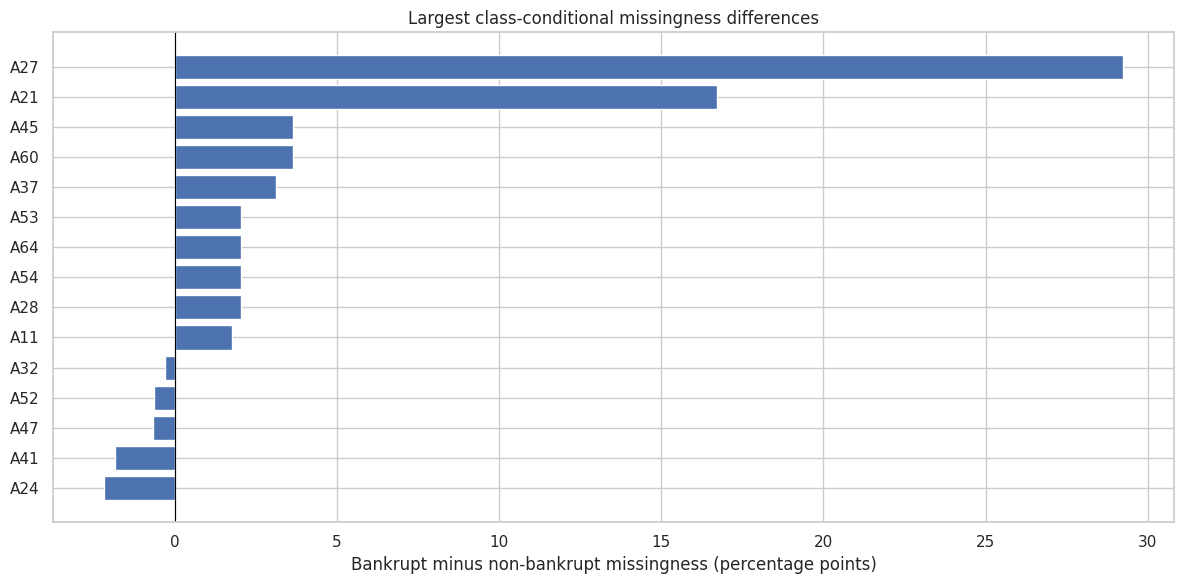

In [7]:
by_class = df.groupby('bankrupt')[features].apply(lambda x: 100*x.isna().mean())
by_class.index=['nonbankrupt','bankrupt']
class_miss = pd.DataFrame({'nonbankrupt_missing_pct':by_class.loc['nonbankrupt'],
                           'bankrupt_missing_pct':by_class.loc['bankrupt']})
class_miss['difference_pp']=class_miss['bankrupt_missing_pct']-class_miss['nonbankrupt_missing_pct']
p_values=[]
for f in features:
    ct = pd.crosstab(df['bankrupt'], df[f].isna())
    p = chi2_contingency(ct,correction=False)[1] if ct.shape==(2,2) else np.nan
    p_values.append(p)
class_miss['chi2_p']=p_values
valid=class_miss['chi2_p'].notna()
class_miss['fdr_q']=np.nan
if valid.any():
    class_miss.loc[valid,'fdr_q']=multipletests(class_miss.loc[valid,'chi2_p'],method='fdr_bh')[1]
class_miss['significant_at_0_05']=class_miss['fdr_q']<.05
class_miss=class_miss.sort_values('difference_pp',key=abs,ascending=False)
display(class_miss.head(20).round(4))
class_miss.to_csv(OUT/'missingness_vs_label.csv')
print('FDR-significant feature missingness indicators:',int(class_miss.significant_at_0_05.sum()))
print('Rows with any missing value, by label (%):')
display(df.assign(any_missing=miss.any(axis=1)).groupby(['cohort','bankrupt'])['any_missing'].mean().mul(100).unstack().round(2))

fig,ax=plt.subplots(figsize=(12,6))
top=class_miss.head(15).sort_values('difference_pp')
ax.barh(top.index,top['difference_pp']);ax.axvline(0,c='black',lw=.8)
ax.set(xlabel='Bankrupt minus non-bankrupt missingness (percentage points)',title='Largest class-conditional missingness differences')
plt.tight_layout();plt.savefig(OUT/'missingness_label_difference.png',dpi=160);plt.show()

## 6. Financial-ratio distributions, skew, and outliers

Ratios can have very long tails (e.g., small denominator effects). We **visualize with quantile clipping only**, keeping raw data unchanged. For model preparation, winsorization/log-like transforms must be fit on training data only and be validated against financial meaning.

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_pct,skew,iqr,iqr_outlier_pct
A56,43278.0,-26.220,5327.862,-1.108300e+06,-0.663,-0.148,0.009,0.053,0.129,0.380,0.987,293.15,0.293,-207.991,0.120,11.657
A20,43278.0,243.021,37545.175,-2.934000e+01,0.000,0.067,15.413,35.150,63.723,143.333,274.385,7809200.00,0.293,207.913,48.310,5.698
A58,43321.0,30.026,5334.454,-1.986900e+02,0.048,0.625,0.875,0.951,0.993,1.143,1.658,1108300.00,0.194,207.047,0.117,11.519
A41,42651.0,7.718,1398.838,-1.234400e+03,-2.202,-0.317,0.027,0.086,0.206,1.004,7.492,288770.00,1.737,206.265,0.179,16.243
A43,43278.0,1074.125,147218.771,-1.158700e+05,9.691,28.596,66.608,99.402,140.698,259.953,659.646,30393000.00,0.293,203.545,74.089,5.391
A44,43278.0,831.109,110050.970,-1.158700e+05,2.958,11.950,34.878,54.768,80.522,157.082,441.419,22584000.00,0.293,200.253,45.645,5.652
A49,43278.0,-0.483,45.152,-9.001000e+03,-0.868,-0.260,-0.027,0.011,0.062,0.190,0.382,178.89,0.293,-184.565,0.089,12.697
A59,43398.0,1.333,122.104,-3.279700e+02,-2.657,0.000,0.000,0.006,0.236,1.549,6.402,23853.00,0.016,177.762,0.236,15.655
A61,43303.0,17.033,553.049,-1.265600e+01,0.610,2.262,4.510,6.636,10.394,29.326,97.640,108000.00,0.235,176.212,5.884,9.080
A5,43316.0,-385.347,61243.026,-1.190300e+07,-2978.500,-280.380,-49.080,-1.034,50.634,324.248,2879.175,1250100.00,0.205,-171.776,99.714,14.309


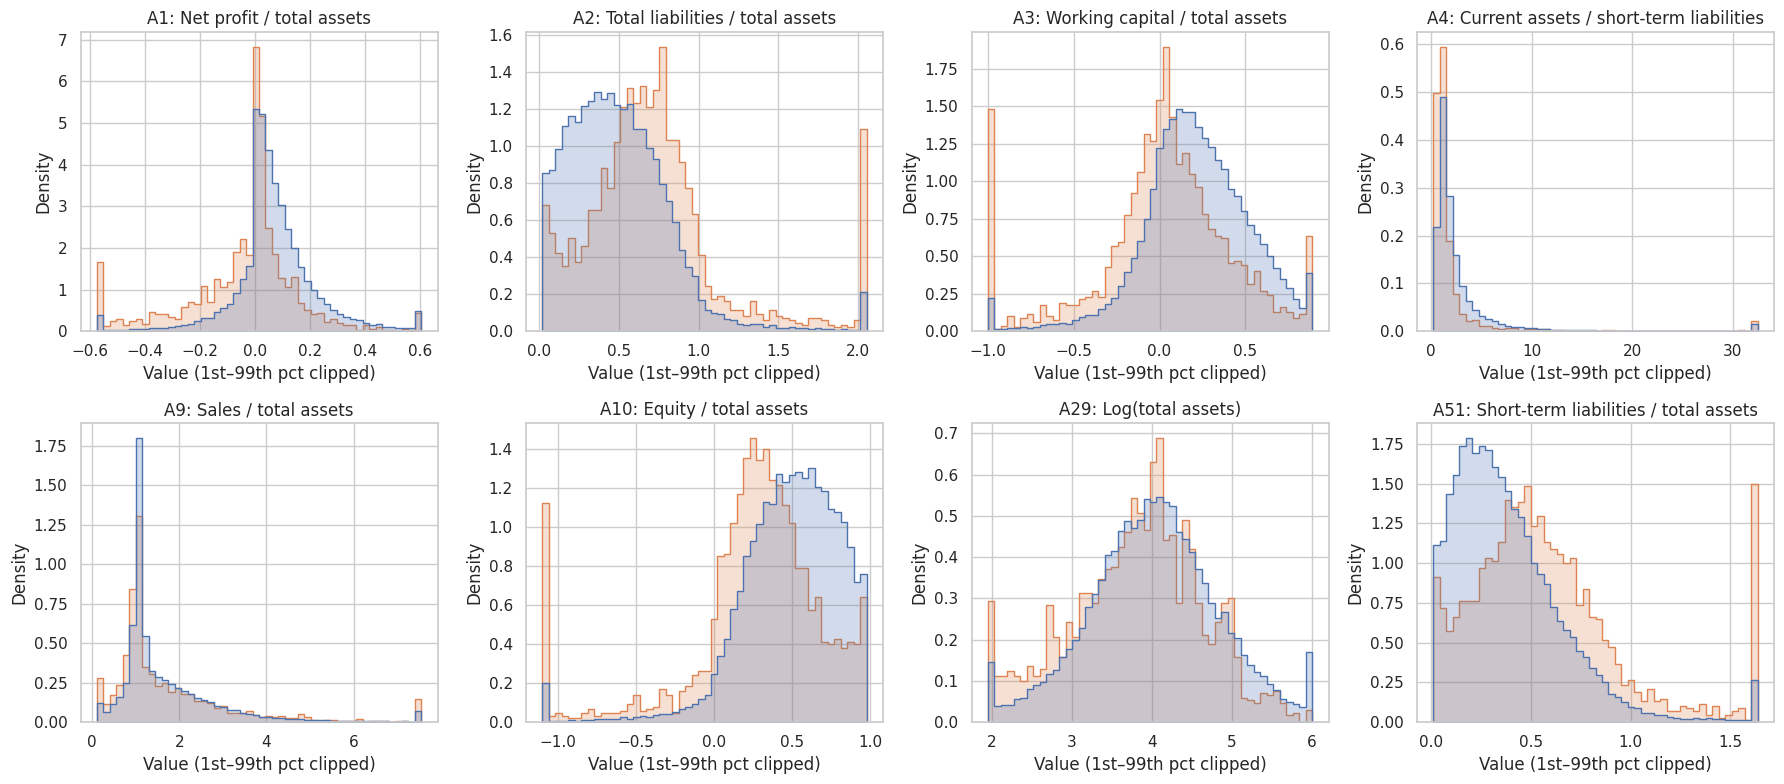

In [8]:
stats = df[features].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99]).T
stats['missing_pct']=100*df[features].isna().mean()
stats['skew']=df[features].skew()
stats['iqr']=stats['75%']-stats['25%']
stats['iqr_outlier_pct']=np.nan
for col in features:
    q1,q3=stats.loc[col,['25%','75%']];iqr=q3-q1
    vals=df[col].dropna()
    if len(vals) and iqr>0:
        stats.loc[col,'iqr_outlier_pct']=100*((vals<q1-1.5*iqr)|(vals>q3+1.5*iqr)).mean()
display(stats.sort_values('skew',key=abs,ascending=False).head(15).round(3))
stats.to_csv(OUT/'feature_descriptives.csv')

# Representative interpretable ratios from UCI documentation
feature_names={'A1':'Net profit / total assets', 'A2':'Total liabilities / total assets',
 'A3':'Working capital / total assets','A4':'Current assets / short-term liabilities',
 'A9':'Sales / total assets','A10':'Equity / total assets',
 'A29':'Log(total assets)','A51':'Short-term liabilities / total assets'}
chosen=list(feature_names)
fig,axes=plt.subplots(2,4,figsize=(18,8))
for ax,f in zip(axes.flat,chosen):
    lo,hi=df[f].quantile([.01,.99]); x=df[f].clip(lo,hi)
    sns.histplot(x=x,hue=df.bankrupt.map({0:'Non-bankrupt',1:'Bankrupt'}),
                 stat='density',common_norm=False,element='step',bins=50,ax=ax,legend=False)
    ax.set(title=f'{f}: {feature_names[f]}',xlabel='Value (1st–99th pct clipped)')
plt.tight_layout();plt.savefig(OUT/'feature_distributions.png',dpi=160);plt.show()

## 7. Class-conditional feature differences

Use medians rather than means as the primary descriptive statistic due to skew and outliers. Effect size is computed as absolute median difference divided by the pooled **interquartile range** (a descriptive ranking, not a causal or predictive importance estimate).

,median_nonbankrupt,median_bankrupt,iqr,abs_median_diff_over_iqr
A38,0.620,0.423,0.352,0.560
A51,0.334,0.512,0.345,0.515
A10,0.515,0.308,0.414,0.501
A25,0.396,0.167,0.461,0.499
A2,0.462,0.669,0.419,0.492
A13,0.071,0.018,0.111,0.483
A62,70.042,106.065,75.076,0.480
A24,0.164,0.013,0.334,0.453
A3,0.204,0.039,0.382,0.432
A11,0.078,0.016,0.151,0.413


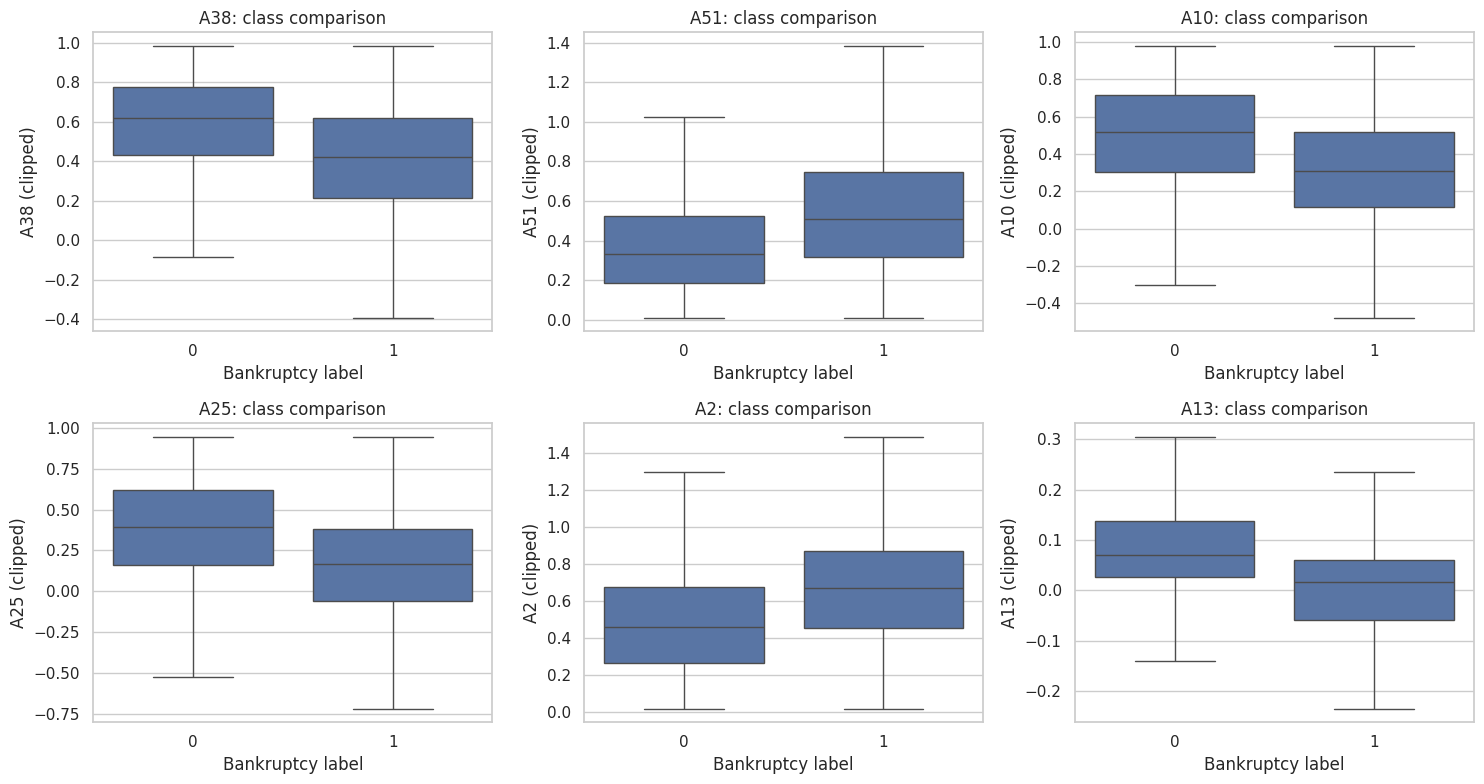

In [9]:
med0=df.loc[df.bankrupt==0,features].median()
med1=df.loc[df.bankrupt==1,features].median()
iqr=df[features].quantile(.75)-df[features].quantile(.25)
sep=pd.DataFrame({'median_nonbankrupt':med0,'median_bankrupt':med1,
                  'iqr':iqr, 'abs_median_diff_over_iqr':(med1-med0).abs()/iqr.replace(0,np.nan)})
sep=sep.sort_values('abs_median_diff_over_iqr',ascending=False)
display(sep.head(20).round(3))
sep.to_csv(OUT/'class_feature_differences.csv')
selected=sep.head(6).index.tolist()
fig,axes=plt.subplots(2,3,figsize=(15,8))
for ax,f in zip(axes.flat,selected):
    lo,hi=df[f].quantile([.01,.99]);plot_df=pd.DataFrame({'label':df.bankrupt,'value':df[f].clip(lo,hi)})
    sns.boxplot(data=plot_df,x='label',y='value',showfliers=False,ax=ax)
    ax.set(xlabel='Bankruptcy label',ylabel=f'{f} (clipped)',title=f'{f}: class comparison')
plt.tight_layout();plt.savefig(OUT/'class_conditional_boxplots.png',dpi=160);plt.show()

## 8. Correlations, redundancy, PCA

High correlation can make joint-distribution learning harder for a GAN. Use pairwise-complete Spearman correlations for exploration (not a substitute for proper missing-value modeling).
Here the median-imputed + robust-scaled PCA below is **visualization only**, and is not evidence that imputing with medians is the optimal final method.

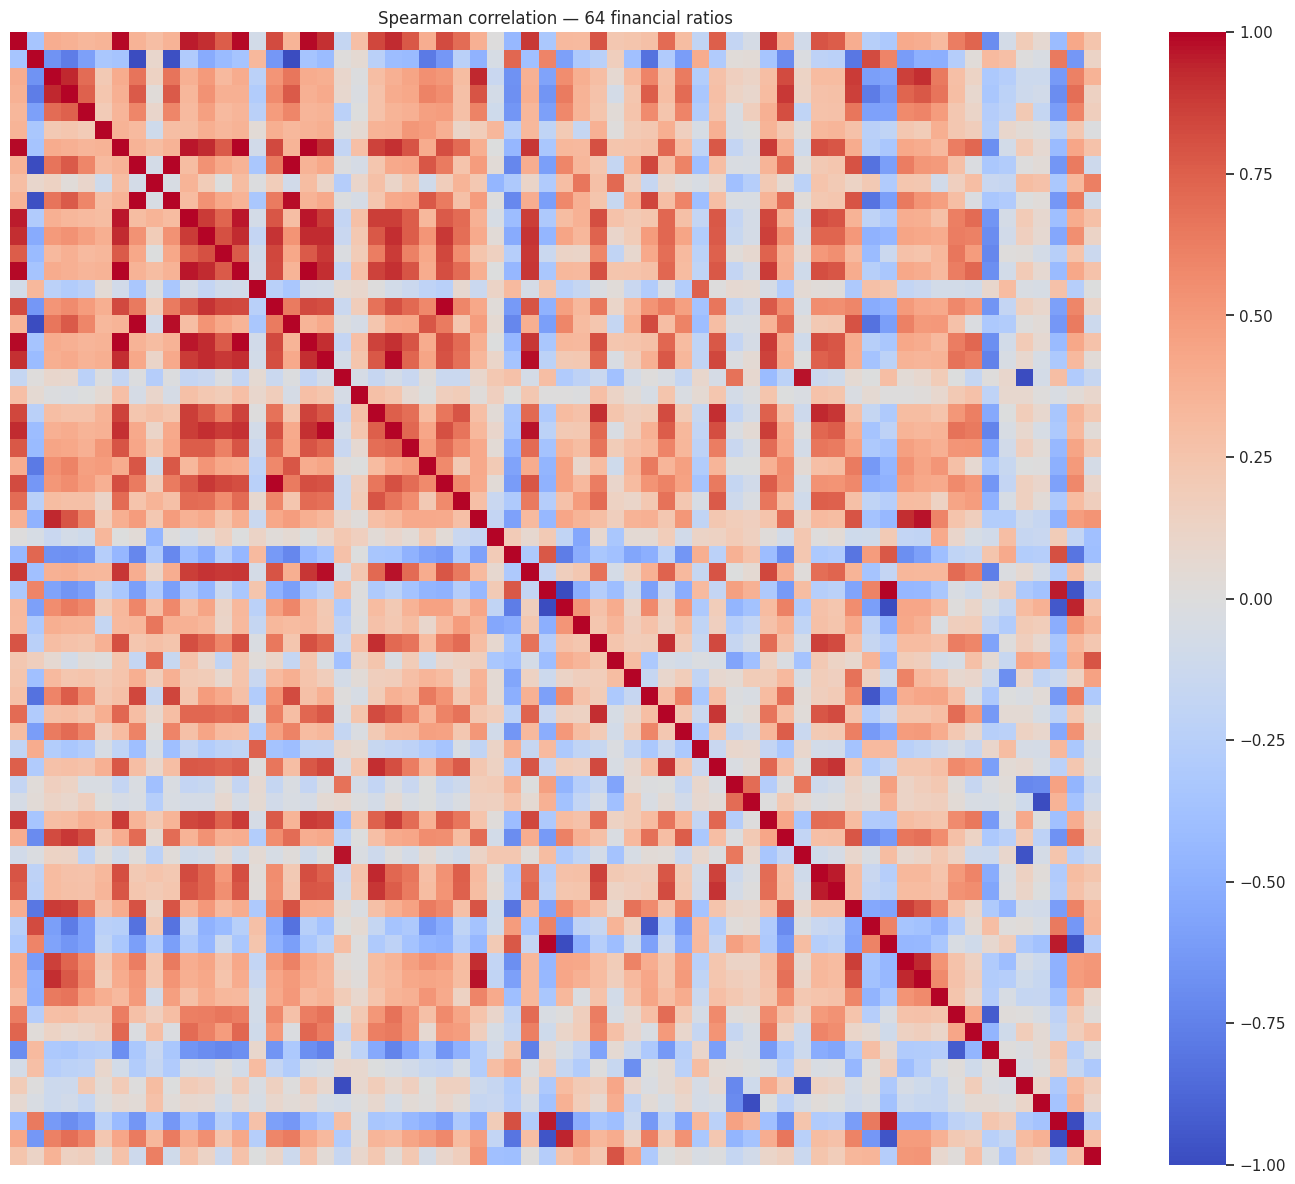

,feature_1,feature_2,spearman_r,abs_r
744,A14,A18,1.000,1.000
369,A7,A14,1.000,1.000
1065,A20,A60,-1.000,1.000
373,A7,A18,1.000,1.000
77,A2,A17,-1.000,1.000
2013,A62,A63,-0.999,0.999
1822,A44,A61,-0.999,0.999
1507,A32,A52,0.998,0.998
1538,A33,A52,-0.998,0.998
1488,A32,A33,-0.997,0.997


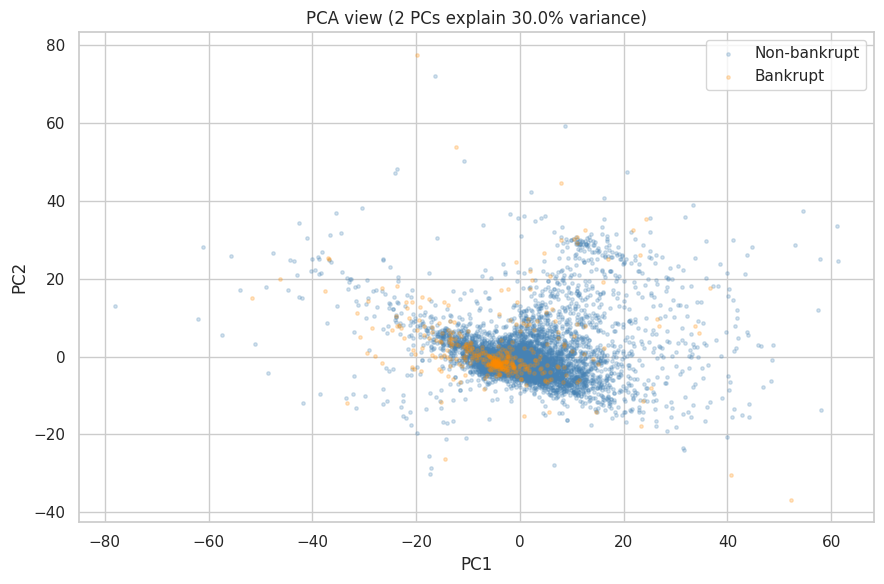

In [10]:
corr=df[features].corr(method='spearman',min_periods=150)
fig,ax=plt.subplots(figsize=(14,12))
sns.heatmap(corr,cmap='coolwarm',center=0,vmin=-1,vmax=1,xticklabels=False,yticklabels=False,ax=ax)
ax.set_title('Spearman correlation — 64 financial ratios');plt.tight_layout()
plt.savefig(OUT/'spearman_correlation.png',dpi=160);plt.show()
upper=corr.where(np.triu(np.ones(corr.shape,dtype=bool),k=1))
pairs=upper.stack().rename('spearman_r').reset_index()
pairs.columns=['feature_1','feature_2','spearman_r']
pairs['abs_r']=pairs['spearman_r'].abs()
display(pairs.sort_values('abs_r',ascending=False).head(15).round(3))
pairs.sort_values('abs_r',ascending=False).to_csv(OUT/'feature_correlations.csv',index=False)

sample=df.sample(n=min(len(df),8000),random_state=RANDOM_STATE)
Xviz=SimpleImputer(strategy='median',keep_empty_features=True).fit_transform(sample[features])
Xviz=RobustScaler().fit_transform(Xviz)
# Clip for chart robustness only
Xviz=np.clip(Xviz,-20,20)
pca=PCA(n_components=2,random_state=RANDOM_STATE)
Z=pca.fit_transform(Xviz)
fig,ax=plt.subplots(figsize=(9,6))
for val,color,label in [(0,'steelblue','Non-bankrupt'),(1,'darkorange','Bankrupt')]:
    mask=sample.bankrupt.to_numpy()==val
    ax.scatter(Z[mask,0],Z[mask,1],s=6,alpha=.23,label=label,c=color)
ax.set(title=f'PCA view (2 PCs explain {pca.explained_variance_ratio_.sum():.1%} variance)',xlabel='PC1',ylabel='PC2')
ax.legend();plt.tight_layout();plt.savefig(OUT/'pca.png',dpi=160);plt.show()

## 9. GAN suitability diagnostics and experiment design

**Proposed main experiment:** imputation-focused GAN (e.g., GAIN) trained on each cohort separately, compared against median, KNN, and iterative imputers. Report reconstruction quality **only on observed values artificially masked** at evaluation time. True missing entries have no known ground truth.

- **Do not impute or standardize before splitting.** Fit preprocessing and GAN only on training observations.
- **Separate cohorts for primary evaluation**; if pooled, encode horizon and explain how duplicate firms cannot be identified from these files.
- **Mask experiments:** random MCAR masks at 10%, 20%, 30%; plus *structured* feature-specific/class-aware missingness scenarios (artificially imposed on observed cells). Do not label these synthetic masks as evidence of the real-world missingness mechanism.
- **Metrics:** masked MAE/RMSE per feature on normalized scale, observed-distribution Wasserstein distance, feature correlation preservation, missing-value downstream PR-AUC and minority-class recall. Compare across bankruptcy classes.
- **Class imbalance:** stratify train/validation/test by label; avoid oversampling the held-out set. If using a conditional GAN, evaluate fidelity for `bankrupt=1` separately; rare events make unconditional models vulnerable to majority-class dominance.
- **Data leakage:** feature masks simulated on validation/test only after splitting. Do not use test labels for imputation when evaluating a deployable bankruptcy predictor; any label-conditional imputer must have a deployment-valid way to obtain its condition.
- **Financial constraints:** assess finite values, ratio sign/scale plausibility, preserved inter-feature dependencies, and outliers; synthetic values should not be assumed economically valid.


In [11]:
# Leakage-aware split demonstration for ONE cohort (e.g. 3year).
# Raw X retains actual NaNs for subsequent GAN mask-building.
source=cohorts['3year']
X=source[features].copy(); y=source['bankrupt'].copy()
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,
                                               stratify=y,random_state=RANDOM_STATE)
X_train,X_val,y_train,y_val=train_test_split(X_train,y_train,test_size=.20,
                                             stratify=y_train,random_state=RANDOM_STATE)
print('Train/val/test rows:',len(X_train),len(X_val),len(X_test))
print('Bankruptcy prevalence:',{'train':round(y_train.mean(),4),'val':round(y_val.mean(),4),'test':round(y_test.mean(),4)})
print('Original training missing-cell rate:',round(X_train.isna().to_numpy().mean(),4))

# Baseline example: a simple median imputer fitted ONLY on training rows.
# Not applied to df/cohorts, so missing values remain available for GAIN.
imp=SimpleImputer(strategy='median',keep_empty_features=True)
X_train_median=imp.fit_transform(X_train)
X_val_median=imp.transform(X_val)
X_test_median=imp.transform(X_test)
assert X_train_median.shape[1]==64 and not np.isnan(X_test_median).any()
print('Median baseline prepared with no held-out fit. Original NaNs preserved in X_train/X_val/X_test.')

Train/val/test rows: 6721 1681 2101
Bankruptcy prevalence: {'train': np.float64(0.0472), 'val': np.float64(0.047), 'test': np.float64(0.0471)}
Original training missing-cell rate: 0.0143
Median baseline prepared with no held-out fit. Original NaNs preserved in X_train/X_val/X_test.


## 10. Export and concise automatic EDA findings

In [12]:
topmiss=missing_by_feature.iloc[0]
print('=== EMPIRICAL EDA SUMMARY ===')
print(f'Rows: {len(df):,}; 64 financial features; five cohorts')
print(f'Pooled bankruptcy prevalence: {df.bankrupt.mean():.2%} ({df.bankrupt.sum():,}/{len(df):,})')
print(f'Pooled non-bankrupt:bankrupt ratio: {(df.bankrupt==0).sum()/df.bankrupt.sum():.1f}:1')
print(f'Missing-feature-cell prevalence: {miss.to_numpy().mean():.2%}')
print(f'Rows with ≥1 missing: {(row_missing>0).mean():.2%}')
print(f'Most missing feature: {missing_by_feature.index[0]} ({topmiss.missing_pct:.2f}%)')
print(f'Number of FDR-significant missingness–label associations: {class_miss.significant_at_0_05.sum()} / 64')
print('Top class-conditional separator by robust median difference:',sep.index[0])
print('Saved plots and CSV summaries in:',OUT.resolve())
print('\nLimitations: pooled samples can contain repeated firms; no firm ID is provided; observational missingness mechanism cannot be identified from observed entries alone.')

=== EMPIRICAL EDA SUMMARY ===
Rows: 43,405; 64 financial features; five cohorts
Pooled bankruptcy prevalence: 4.82% (2,091/43,405)
Pooled non-bankrupt:bankrupt ratio: 19.8:1
Missing-feature-cell prevalence: 1.49%
Rows with ≥1 missing: 54.00%
Most missing feature: A37 (43.74%)
Number of FDR-significant missingness–label associations: 16 / 64
Top class-conditional separator by robust median difference: A38
Saved plots and CSV summaries in: /content/outputs/polish_eda

Limitations: pooled samples can contain repeated firms; no firm ID is provided; observational missingness mechanism cannot be identified from observed entries alone.


### Citation

Tomczak, S. (2016). *Polish Companies Bankruptcy*. UCI Machine Learning Repository. DOI: [10.24432/C5F600](https://doi.org/10.24432/C5F600).

**Important:** `1year` predicts 5 years ahead, while `5year` predicts 1 year ahead; this is **not** an ordinary time-indexed sequence dataset like six-month customer histories.

## 11. Download the EDA outputs from Google Colab

After **Runtime → Run all**, run this cell to save every generated CSV and plot as one ZIP.

In [13]:
import shutil
archive_path = shutil.make_archive(str(OUT), 'zip', root_dir=OUT)
print('Created:', archive_path)
if Path('/content').exists():
    from google.colab import files
    files.download(archive_path)


Created: /content/outputs/polish_eda.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>